# YOLOv8 Image Detection Pipeline

This notebook is the end-to-end image detection pipeline: load an image, run YOLOv8 with Neat, parse decoded boxes, scale detections back to the original image, draw labels, and display the result.

Notebook 05 focused on the BBOX payload format. This notebook uses the same decode idea in a complete image workflow.

## Import Packages

In [1]:
from pathlib import Path
import struct
import numpy as np
import cv2
from IPython.display import Image, display
import pyneat


## Load COCO Labels

The decoded YOLO class id maps to a COCO object label. The label file stores one class name per line in class-id order.

In [2]:
COCO_LABELS_PATH = Path("../assets/coco_labels.txt")
coco_classes = COCO_LABELS_PATH.read_text().splitlines()

print("labels path:", COCO_LABELS_PATH)
print("COCO classes:", len(coco_classes))
print("first labels:", coco_classes[:5])


labels path: ../assets/coco_labels.txt
COCO classes: 80
first labels: ['person', 'bicycle', 'car', 'motorcycle', 'airplane']


## Select Model And Image

The model input frame is `640 x 640`. The original image can be any size; later we scale decoded boxes back to the original image coordinates.

In [3]:
MODEL_PATH = Path("../assets/models/yolo_v8s_mpk.tar.gz")
IMAGE_PATH = Path("../assets/images/image.png")
MODEL_W = 640
MODEL_H = 640

print("model path:", MODEL_PATH)
print("model exists:", MODEL_PATH.exists())
print("image path:", IMAGE_PATH)
print("labels exists:", COCO_LABELS_PATH.exists())


model path: ../assets/models/yolo_v8s_mpk.tar.gz
model exists: True
image path: ../assets/images/image.png
labels exists: True


## Load And Display The Image

OpenCV reads BGR images. The display helper below uses the original image file so you can see the input before detection.

image: (563, 1000, 3) uint8


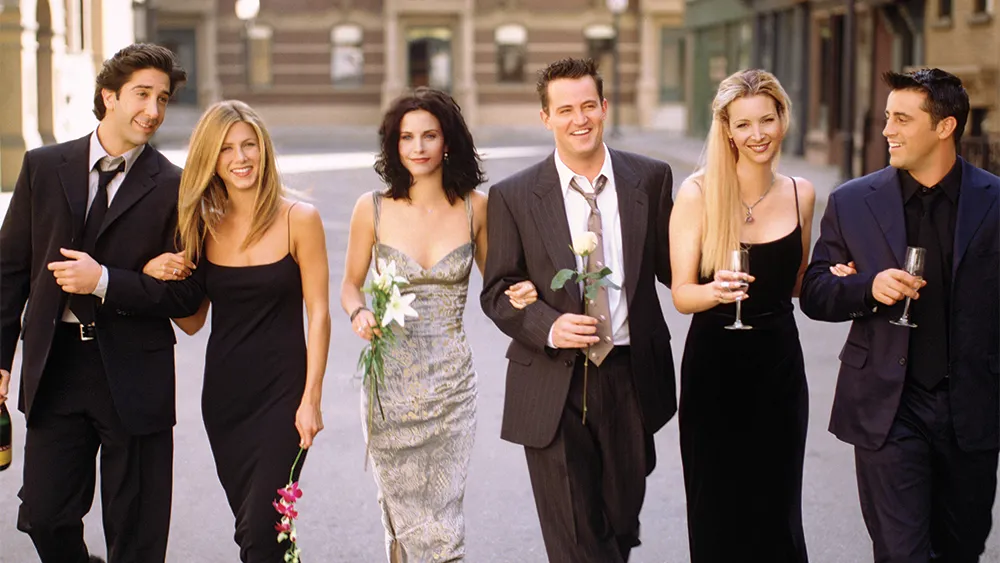

In [4]:
image_bgr = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
image_h, image_w = image_bgr.shape[0], image_bgr.shape[1]

print("image:", image_bgr.shape, image_bgr.dtype)
display(Image(filename=str(IMAGE_PATH)))


## Prepare Detector Input

Create a BGR `pyneat.Tensor` from the original image. In Option 1, Neat preprocessing will resize this tensor before YOLO inference.


In [5]:
input_tensor_bgr = pyneat.Tensor.from_numpy(
    image_bgr,
    copy=True,
    image_format=pyneat.PixelFormat.BGR,
)
print("input tensor:", tuple(input_tensor_bgr.shape))


input tensor: (563, 1000, 3)


## Configure YOLOv8 Model Options

These options describe input preprocessing and request Neat-managed YOLOv8 box decode.

In [6]:
opt = pyneat.ModelOptions()  # Create model options for the YOLOv8 detection package.

opt.preprocess.kind = pyneat.InputKind.Image  # Tell Neat that the application input is an image.
opt.preprocess.color_convert.input_format = pyneat.PreprocessColorFormat.BGR  # The tensor passed below is BGR.

opt.preprocess.resize.enable = pyneat.AutoFlag.On  # Enable resize inside the Neat preprocessing route.
opt.preprocess.resize.width = MODEL_W  # Target model input width for YOLOv8.
opt.preprocess.resize.height = MODEL_H  # Target model input height for YOLOv8.
opt.preprocess.resize.mode = pyneat.ResizeMode.Letterbox  # Preserve aspect ratio and pad to the detector frame.

opt.preprocess.preset = pyneat.NormalizePreset.COCO_YOLO  # YOLO/COCO normalization preset.

opt.decode_type = pyneat.BoxDecodeType.YoloV8  # Decode YOLOv8 output into a BBOX payload.
opt.boxdecode_original_width = image_w  # Ask BoxDecode to output boxes in original-image width coordinates.
opt.boxdecode_original_height = image_h  # Ask BoxDecode to output boxes in original-image height coordinates.
opt.score_threshold = 0.55  # Minimum confidence score for keeping boxes.
opt.nms_iou_threshold = 0.30  # IoU threshold for non-maximum suppression.
opt.top_k = 100  # Maximum number of decoded detections to keep.
opt.num_classes = len(coco_classes)  # Number of COCO detection classes.

opt.verbose = pyneat.VerboseOptions.quiet()  # Suppress model-level verbose diagnostics.

print("YOLOv8 ModelOptions ready")


YOLOv8 ModelOptions ready


## Option 1 - Neat Graph with Neat Preprocessing

This option sends the original image tensor into a graph. Neat handles resize, YOLO inference, and box decode. Because `boxdecode_original_width` and `boxdecode_original_height` are set to the original image size, decoded boxes can be drawn directly on `image_bgr`.


In [7]:
model = pyneat.Model(str(MODEL_PATH), opt)

In [8]:
# graph.add(...) composes this simple linear pipeline by insertion order.
inference_graph = pyneat.Graph("yolov8-app")
inference_graph.add(pyneat.nodes.input("image"))
inference_graph.add(model)
inference_graph.add(pyneat.nodes.output("detections"))


In [9]:
print(inference_graph.describe())

0) Input  [image]
1) Preproc
2) ModelFragment  [infer]
3) SimaBoxDecode
4) Output  [detections]


In [10]:
run = inference_graph.build()
try:
    run.push("image", [input_tensor_bgr])
    run.close_input()
    outputs = run.pull_tensors("detections", timeout_ms=20000)
finally:
    run.close()

print("[OK] Graph app completed")

[OK] Graph app completed


[1/4] Initializing runtime...
[2/4] Building graph...
[3/4] Starting pipeline...
[4/4] Graph ready (0 ms)


## Decode BBOX with pyneat

`pyneat.decode_bbox(...)` converts Neat's BBOX payload into rows of `x1, y1, x2, y2, score, class_id`.


In [11]:
decoded = pyneat.decode_bbox(outputs)
for x1, y1, x2, y2, score, cls in decoded[0].to_numpy():
    name = coco_classes[int(cls)]
    print(f"{name:<8} {score:.2f}  [{x1:4.0f} {y1:4.0f} {x2:4.0f} {y2:4.0f}]")


person   0.71  [ 480   56  679  556]
person   0.71  [   1   39  196  558]
person   0.71  [ 797   65 1000  556]
person   0.71  [ 338   87  487  557]
person   0.71  [ 668   67  817  555]
person   0.70  [ 151   97  331  555]
tie      0.64  [  58  156  126  339]
tie      0.56  [ 570  175  608  274]
wine glass 0.67  [ 890  246  926  325]
wine glass 0.66  [ 718  249  756  329]


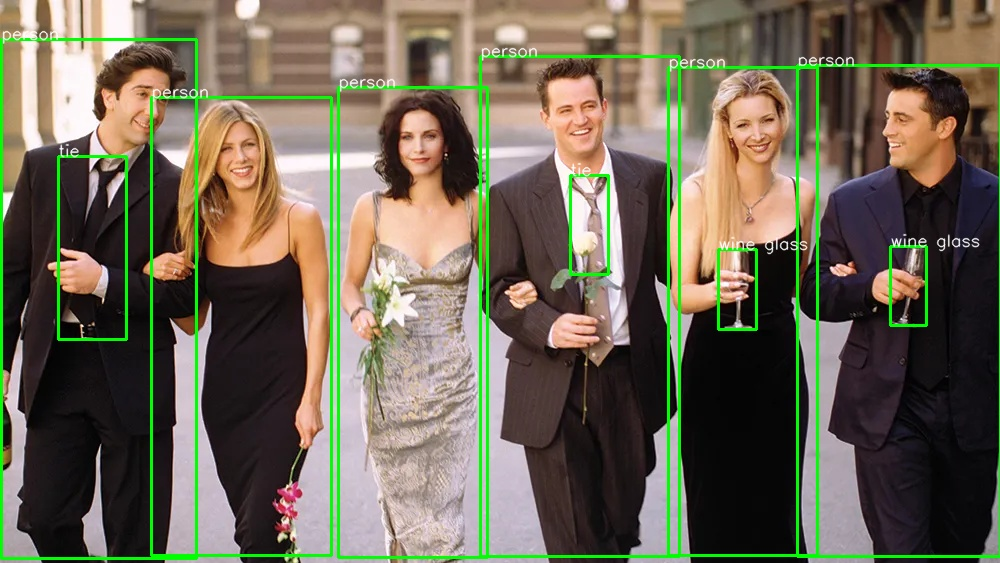

In [12]:
output_img = image_bgr.copy()
for x1, y1, x2, y2, score, cls in decoded[0].to_numpy():
    x1 = int(x1)
    y1 = int(y1)
    x2 = int(x2)
    y2 = int(y2)
    class_name = coco_classes[int(cls)]
    cv2.rectangle(output_img, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(output_img, class_name, (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

from IPython.display import Image, display
cv2.imwrite("result-yolov8.jpg", output_img)
display(Image("result-yolov8.jpg"))

## Option 2 - Manual Letterbox with model.run(...)

This option performs letterbox resize in Python, then runs the model directly. The decoded boxes are in the resized `640 x 640` letterbox coordinate space, so draw them on `image_bgr_resize`.


In [13]:
def letterbox_image(img, target_size=(640, 640), pad_color=(255, 255, 255)):
    """
    Resize image while preserving aspect ratio, then pad to target_size.

    Args:
        img: input image, HWC, BGR or RGB.
        target_size: (width, height)
        pad_color: padding color, same channel order as img.

    Returns:
        padded: resized + padded image
    """
    target_w, target_h = target_size
    orig_h, orig_w = img.shape[:2]

    scale = min(target_w / orig_w, target_h / orig_h)
    new_w = int(round(orig_w * scale))
    new_h = int(round(orig_h * scale))

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    pad_w = target_w - new_w
    pad_h = target_h - new_h

    pad_left = pad_w // 2
    pad_right = pad_w - pad_left
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top

    padded = cv2.copyMakeBorder(
        resized,
        pad_top,
        pad_bottom,
        pad_left,
        pad_right,
        cv2.BORDER_CONSTANT,
        value=pad_color,
    )

    return padded

In [14]:
image_bgr_resize = letterbox_image(image_bgr)

input_tensor_bgr = pyneat.Tensor.from_numpy(
    image_bgr_resize,
    copy=True,
    image_format=pyneat.PixelFormat.BGR,
)

In [16]:
opt = pyneat.ModelOptions()  # Create model options for the YOLOv8 detection package.

opt.preprocess.kind = pyneat.InputKind.Image  # Tell Neat that the application input is an image.
opt.preprocess.color_convert.input_format = pyneat.PreprocessColorFormat.BGR  # Input tensor color format.

opt.preprocess.preset = pyneat.NormalizePreset.COCO_YOLO  # YOLO/COCO normalization preset.

opt.decode_type = pyneat.BoxDecodeType.YoloV8  # Decode YOLOv8 output into a BBOX payload.
opt.score_threshold = 0.55  # Minimum confidence score for keeping boxes.
opt.nms_iou_threshold = 0.30  # IoU threshold for non-maximum suppression.
opt.top_k = 100  # Maximum number of decoded detections to keep.
opt.num_classes = len(coco_classes)  # Number of COCO detection classes.

opt.verbose = pyneat.VerboseOptions.quiet()  # Suppress model-level verbose diagnostics.

print("YOLOv8 ModelOptions ready")


model = pyneat.Model(str(MODEL_PATH), opt)
outputs = model.run([input_tensor_bgr])
decoded = pyneat.decode_bbox(outputs)
for x1, y1, x2, y2, score, cls in decoded[0].to_numpy():
    name = coco_classes[int(cls)]
    print(f"{name:<8} {score:.2f}  [{x1:4.0f} {y1:4.0f} {x2:4.0f} {y2:4.0f}]")

YOLOv8 ModelOptions ready
Configuring for the decoding type: 5:yolov8
Configured for subtensors: 6
Derived configuration for YOLO : num_anchors: 1 score tensor: 1 xy_tensor 0 extent_tensor 0
Additional configuration for YOLO : none


[1/4] Initializing runtime...
[2/4] Preparing input stream...
[3/4] Building graph...
[4/4] Graph ready (82 ms)


Configuring for the decoding type: 5:yolov8
Configured for subtensors: 6
Derived configuration for YOLO : num_anchors: 1 score tensor: 1 xy_tensor 0 extent_tensor 0
Additional configuration for YOLO : none
person   0.71  [ 513  182  639  496]
person   0.71  [   0  166  125  496]
person   0.71  [ 306  177  434  497]
person   0.71  [ 216  196  311  496]
person   0.71  [ 428  184  523  495]
person   0.68  [  95  203  212  494]
tie      0.65  [  37  240   80  358]
tie      0.55  [ 365  252  389  296]
wine glass 0.68  [ 569  299  593  349]
wine glass 0.66  [ 459  300  483  351]


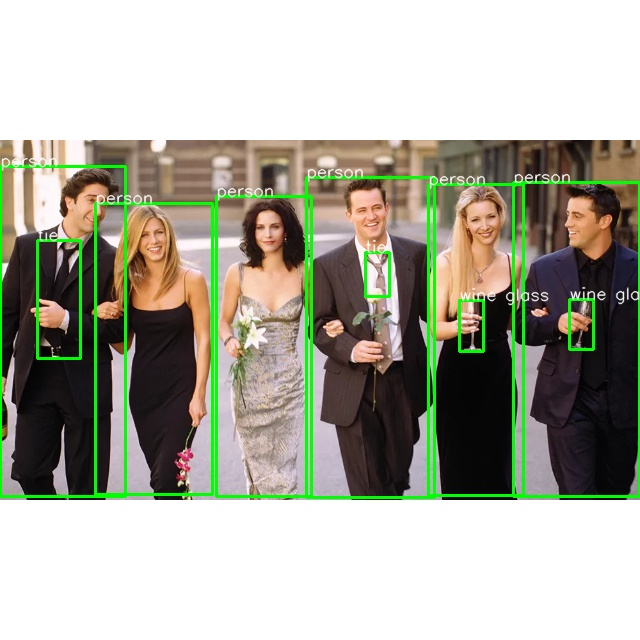

In [17]:
output_img = image_bgr_resize.copy()
for x1, y1, x2, y2, score, cls in decoded[0].to_numpy():
    x1 = int(x1)
    y1 = int(y1)
    x2 = int(x2)
    y2 = int(y2)
    class_name = coco_classes[int(cls)]
    cv2.rectangle(output_img, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(output_img, class_name, (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

from IPython.display import Image, display
cv2.imwrite("result-yolov8-2.jpg", output_img)
display(Image("result-yolov8-2.jpg"))

## Option 3 - Manual Stretch Resize with model.run(...)

This option uses direct OpenCV resize to stretch the image to `640 x 640`. The decoded boxes are in the stretched detector-frame coordinate space, so draw them on the stretched image.


In [18]:
image_bgr_resize = cv2.resize(
    image_bgr,
    (MODEL_W, MODEL_H),
    interpolation=cv2.INTER_LINEAR,
)

input_tensor_bgr = pyneat.Tensor.from_numpy(
    image_bgr_resize,
    copy=True,
    image_format=pyneat.PixelFormat.BGR,
)

In [19]:
opt = pyneat.ModelOptions()  # Create model options for the YOLOv8 detection package.

opt.preprocess.kind = pyneat.InputKind.Image  # Tell Neat that the application input is an image.
opt.preprocess.color_convert.input_format = pyneat.PreprocessColorFormat.BGR  # Input tensor color format.

opt.preprocess.preset = pyneat.NormalizePreset.COCO_YOLO  # YOLO/COCO normalization preset.

opt.decode_type = pyneat.BoxDecodeType.YoloV8  # Decode YOLOv8 output into a BBOX payload.
opt.score_threshold = 0.55  # Minimum confidence score for keeping boxes.
opt.nms_iou_threshold = 0.30  # IoU threshold for non-maximum suppression.
opt.top_k = 100  # Maximum number of decoded detections to keep.
opt.num_classes = len(coco_classes)  # Number of COCO detection classes.

opt.verbose = pyneat.VerboseOptions.quiet()  # Suppress model-level verbose diagnostics.

print("YOLOv8 ModelOptions ready")


model = pyneat.Model(str(MODEL_PATH), opt)
outputs = model.run([input_tensor_bgr])
decoded = pyneat.decode_bbox(outputs)
for x1, y1, x2, y2, score, cls in decoded[0].to_numpy():
    name = coco_classes[int(cls)]
    print(f"{name:<8} {score:.2f}  [{x1:4.0f} {y1:4.0f} {x2:4.0f} {y2:4.0f}]")

YOLOv8 ModelOptions ready
person   0.71  [ 511   76  639  640]
person   0.70  [ 305   87  436  640]
person   0.70  [   0   53  125  639]
person   0.70  [ 217   98  313  640]
person   0.68  [ 426   78  523  640]
person   0.63  [  60  111  213  640]
tie      0.58  [  48  176   80  286]
tie      0.57  [ 363  198  393  392]
wine glass 0.63  [ 459  282  484  375]
wine glass 0.58  [ 567  281  592  373]


[1/4] Initializing runtime...
[2/4] Preparing input stream...
[3/4] Building graph...
[4/4] Graph ready (80 ms)


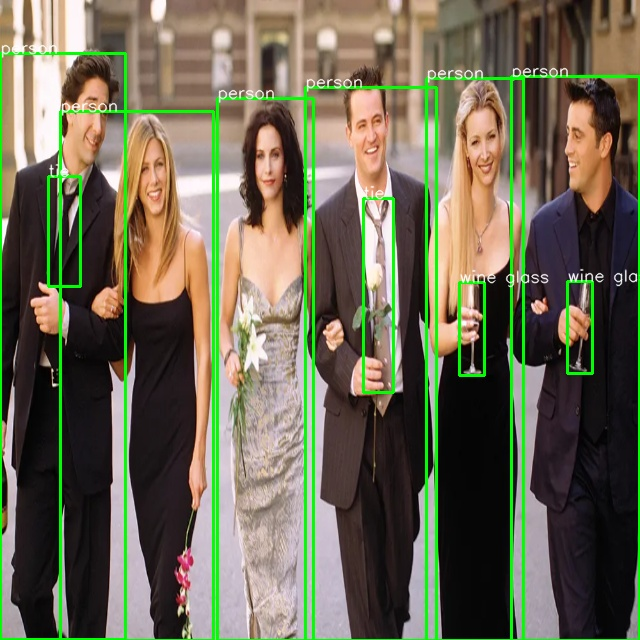

In [20]:
output_img = image_bgr_resize.copy()
for x1, y1, x2, y2, score, cls in decoded[0].to_numpy():
    x1 = int(x1)
    y1 = int(y1)
    x2 = int(x2)
    y2 = int(y2)
    class_name = coco_classes[int(cls)]
    cv2.rectangle(output_img, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(output_img, class_name, (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)

from IPython.display import Image, display
cv2.imwrite("result-yolov8-3.jpg", output_img)
display(Image("result-yolov8-3.jpg"))

## What To Remember

`pyneat.decode_bbox(...)` converts Neat's decoded BBOX output into a friendlier tensor of `x1, y1, x2, y2, score, class_id` rows. If you draw on a different image size than the detector input, scale the coordinates carefully.

`ModelOptions` describes both preprocessing and postprocessing. The preprocessing fields describe input image format and normalization; the decode fields tell Neat to turn YOLOv8 outputs into detection boxes.

A linear graph can be composed by `graph.add(...)` order. In this notebook, `Input -> Model -> Output` expands internally into `Input -> Preproc -> ModelFragment -> SimaBoxDecode -> Output`.

A YOLO image pipeline is sensitive to preprocessing. Letterbox preserves aspect ratio and pads the image, while direct resize stretches the image to the detector frame. These choices can change confidence and box placement.


## References

- Public tutorial: [read detection boxes](https://developer.sima.ai/software/tutorials/read-detection-boxes).
- Core source: [read_detection_boxes.py](https://github.com/sima-neat/core/blob/main/tutorials/007_read_detection_boxes/read_detection_boxes.py).
- Graph app box decode example: [run_an_app.md](https://github.com/sima-neat/core/blob/main/docs/develop-apps/hello-neat/run_an_app.md).
- BoxDecode helper reference: [boxdecode_decode_types.md](https://github.com/sima-neat/core/blob/main/docs/reference/boxdecode_decode_types.md).
- COCO labels follow the standard 80-class object detection order used by YOLO COCO models.